In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Load dataset
df = pd.read_csv("prison_data.csv")

# Display first rows
df.head()

,Unnamed: 0,State,Total/Sex,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,0,National Statistics,Total,307276,314457,329821,369930,413806,436855,462002,502507,544972,585084,627600,712364,773919,825559,882500,969301,1054702,1125874,1181919,1240659,1307154,1363686,1394231,1404032,1440144,1468601,1497100,1525910,1568674,1596835,1608282,1615487,1613803,1598968,1570397,1576950,1562319,1526603,1505397
1,1,National Statistics,Male,294530,301462,316401,354393,396021,417835,441208,479359,518441,555961,594996,671752,729840,777908,832093,911044,990306,1057406,1107109,1161468,1222273,1273258,1300997,1311053,1342513,1367755,1392278,1418392,1456366,1482524,1493670,1502002,1500936,1487561,1461625,1465592,1449291,1415112,1393975
2,2,National Statistics,Female,12746,12995,13420,15537,17785,19020,20794,23148,26531,29123,32604,40612,44079,47651,50407,58257,64396,68468,74810,79191,84881,90428,93234,92979,97631,100846,104822,107518,112308,114311,114612,113485,112867,111407,108772,111358,113028,111491,111422
3,3,Federal Institutions,Total,29803,26371,24363,28133,29673,31926,34263,40223,44408,48300,49928,59171,65526,71608,80259,89587,95034,100250,105544,112973,123041,135246,145416,156993,163528,173059,180328,187618,193046,199618,201280,208118,209771,216362,217815,215866,210567,196455,189192
4,4,Federal Institutions,Male,27975,24835,22964,26574,28046,30172,32267,37819,41575,45273,46686,54736,60515,65954,73860,82696,87894,92852,97844,104667,113855,125333,135171,146020,152294,161424,168164,175196,180071,186280,188007,194493,196222,202462,203766,201697,196568,183502,176495


In [3]:
# Dataset info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  162 non-null    int64
 1   State       162 non-null    str  
 2   Total/Sex   162 non-null    str  
 3   1978        162 non-null    int64
 4   1979        162 non-null    int64
 5   1980        162 non-null    int64
 6   1981        162 non-null    int64
 7   1982        162 non-null    int64
 8   1983        162 non-null    int64
 9   1984        162 non-null    int64
 10  1985        162 non-null    int64
 11  1986        162 non-null    int64
 12  1987        162 non-null    int64
 13  1988        162 non-null    int64
 14  1989        162 non-null    int64
 15  1990        162 non-null    int64
 16  1991        162 non-null    int64
 17  1992        162 non-null    int64
 18  1993        162 non-null    int64
 19  1994        162 non-null    int64
 20  1995        162 non-null    int64
 21  1996

Unnamed: 0    0
State         0
Total/Sex     0
1978          0
1979          0
1980          0
1981          0
1982          0
1983          0
1984          0
1985          0
1986          0
1987          0
1988          0
1989          0
1990          0
1991          0
1992          0
1993          0
1994          0
1995          0
1996          0
1997          0
1998          0
1999          0
2000          0
2001          0
2002          0
2003          0
2004          0
2005          0
2006          0
2007          0
2008          0
2009          0
2010          0
2011          0
2012          0
2013          0
2014          0
2015          0
2016          0
dtype: int64

In [4]:
# Example: fill missing numeric values with mean
df = df.fillna(df.mean(numeric_only=True))

In [5]:
# Select only numeric columns
X = df.select_dtypes(include=['int64', 'float64'])

X.head()

,Unnamed: 0,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,0,307276,314457,329821,369930,413806,436855,462002,502507,544972,585084,627600,712364,773919,825559,882500,969301,1054702,1125874,1181919,1240659,1307154,1363686,1394231,1404032,1440144,1468601,1497100,1525910,1568674,1596835,1608282,1615487,1613803,1598968,1570397,1576950,1562319,1526603,1505397
1,1,294530,301462,316401,354393,396021,417835,441208,479359,518441,555961,594996,671752,729840,777908,832093,911044,990306,1057406,1107109,1161468,1222273,1273258,1300997,1311053,1342513,1367755,1392278,1418392,1456366,1482524,1493670,1502002,1500936,1487561,1461625,1465592,1449291,1415112,1393975
2,2,12746,12995,13420,15537,17785,19020,20794,23148,26531,29123,32604,40612,44079,47651,50407,58257,64396,68468,74810,79191,84881,90428,93234,92979,97631,100846,104822,107518,112308,114311,114612,113485,112867,111407,108772,111358,113028,111491,111422
3,3,29803,26371,24363,28133,29673,31926,34263,40223,44408,48300,49928,59171,65526,71608,80259,89587,95034,100250,105544,112973,123041,135246,145416,156993,163528,173059,180328,187618,193046,199618,201280,208118,209771,216362,217815,215866,210567,196455,189192
4,4,27975,24835,22964,26574,28046,30172,32267,37819,41575,45273,46686,54736,60515,65954,73860,82696,87894,92852,97844,104667,113855,125333,135171,146020,152294,161424,168164,175196,180071,186280,188007,194493,196222,202462,203766,201697,196568,183502,176495


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

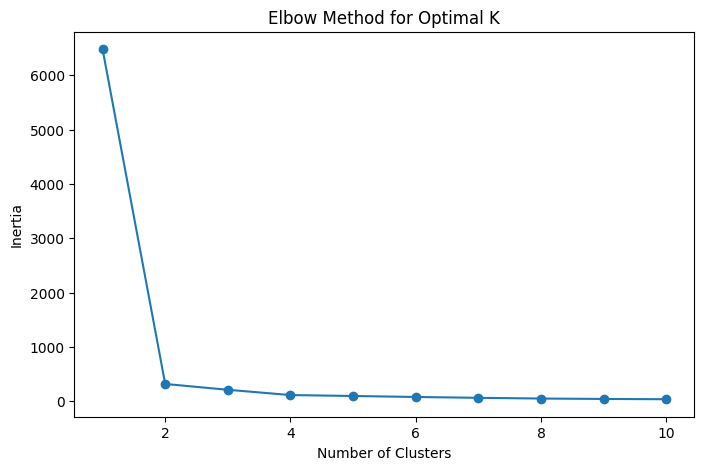

In [7]:
inertia = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,Unnamed: 0,State,Total/Sex,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,Cluster
0,0,National Statistics,Total,307276,314457,329821,369930,413806,436855,462002,502507,544972,585084,627600,712364,773919,825559,882500,969301,1054702,1125874,1181919,1240659,1307154,1363686,1394231,1404032,1440144,1468601,1497100,1525910,1568674,1596835,1608282,1615487,1613803,1598968,1570397,1576950,1562319,1526603,1505397,1
1,1,National Statistics,Male,294530,301462,316401,354393,396021,417835,441208,479359,518441,555961,594996,671752,729840,777908,832093,911044,990306,1057406,1107109,1161468,1222273,1273258,1300997,1311053,1342513,1367755,1392278,1418392,1456366,1482524,1493670,1502002,1500936,1487561,1461625,1465592,1449291,1415112,1393975,1
2,2,National Statistics,Female,12746,12995,13420,15537,17785,19020,20794,23148,26531,29123,32604,40612,44079,47651,50407,58257,64396,68468,74810,79191,84881,90428,93234,92979,97631,100846,104822,107518,112308,114311,114612,113485,112867,111407,108772,111358,113028,111491,111422,2
3,3,Federal Institutions,Total,29803,26371,24363,28133,29673,31926,34263,40223,44408,48300,49928,59171,65526,71608,80259,89587,95034,100250,105544,112973,123041,135246,145416,156993,163528,173059,180328,187618,193046,199618,201280,208118,209771,216362,217815,215866,210567,196455,189192,2
4,4,Federal Institutions,Male,27975,24835,22964,26574,28046,30172,32267,37819,41575,45273,46686,54736,60515,65954,73860,82696,87894,92852,97844,104667,113855,125333,135171,146020,152294,161424,168164,175196,180071,186280,188007,194493,196222,202462,203766,201697,196568,183502,176495,2


In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

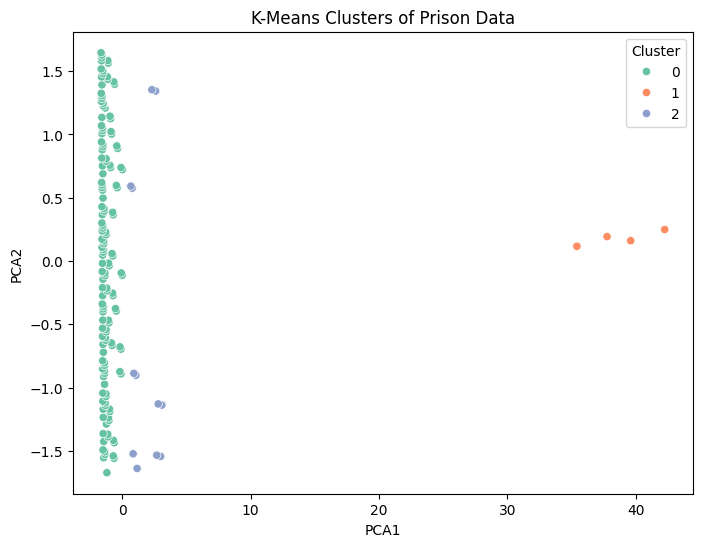

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='Set2'
)

plt.title("K-Means Clusters of Prison Data")
plt.show()